IntelliCode: AI-Powered Software Defect Prediction System

 Introduction

Software defects are one of the major causes of software failures, increased maintenance costs, and project delays. Detecting defect-prone modules early helps software teams prioritize testing efforts and improve software quality.

This project, IntelliCode, uses Machine Learning techniques to predict whether a software module is likely to contain defects based on software metrics from the NASA JM1 dataset.

Problem Statement

Traditional software testing requires significant time and resources. Identifying defect-prone modules manually is challenging, especially in large software systems.

The objective of this project is to build a machine learning model that predicts software defects using software metrics, enabling teams to focus testing efforts on high-risk modules.

In [49]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
df = pd.read_csv(r"C:\Users\Deepika B R\Downloads\archive (3)\jm1.csv")

In [51]:
df.head()

,id,loc,v(g),ev(g),iv(g),n,v,l,d,i,...,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
0,1,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,...,2,2,2,2,1.2,1.2,1.2,1.2,1.4,False
1,2,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,...,1,1,1,1,1,1,1,1,1,True
2,3,72.0,7.0,1.0,6.0,198.0,1134.13,0.05,20.31,55.85,...,51,10,8,1,17,36,112,86,13,True
3,4,190.0,3.0,1.0,3.0,600.0,4348.76,0.06,17.06,254.87,...,129,29,28,2,17,135,329,271,5,True
4,5,37.0,4.0,1.0,4.0,126.0,599.12,0.06,17.19,34.86,...,28,1,6,0,11,16,76,50,7,True


In [52]:
df.shape

(10885, 23)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10885 entries, 0 to 10884
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 10885 non-null  int64  
 1   loc                10885 non-null  float64
 2   v(g)               10885 non-null  float64
 3   ev(g)              10885 non-null  float64
 4   iv(g)              10885 non-null  float64
 5   n                  10885 non-null  float64
 6   v                  10885 non-null  float64
 7   l                  10885 non-null  float64
 8   d                  10885 non-null  float64
 9   i                  10885 non-null  float64
 10  e                  10885 non-null  float64
 11  b                  10885 non-null  float64
 12  t                  10885 non-null  float64
 13  lOCode             10885 non-null  int64  
 14  lOComment          10885 non-null  int64  
 15  lOBlank            10885 non-null  int64  
 16  locCodeAndComment  108

In [54]:
df.describe()

,id,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,b,t,lOCode,lOComment,lOBlank,locCodeAndComment
count,10885.000000,10885.000000,10885.000000,10885.000000,10885.000000,10885.000000,10885.000000,10885.000000,10885.000000,10885.000000,1.088500e+04,10885.000000,1.088500e+04,10885.000000,10885.000000,10885.00000,10885.000000
mean,5443.000000,42.016178,6.348590,3.401047,4.001599,114.389738,673.758017,0.135335,14.177237,29.439544,3.683637e+04,0.224766,2.046465e+03,26.252274,2.737529,4.62554,0.370785
std,3142.373174,76.593332,13.019695,6.771869,9.116889,249.502091,1938.856196,0.160538,18.709900,34.418313,4.343678e+05,0.646408,2.413154e+04,59.611201,9.008608,9.96813,1.907969
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.00000,0.000000
25%,2722.000000,11.000000,2.000000,1.000000,1.000000,14.000000,48.430000,0.030000,3.000000,11.860000,1.619400e+02,0.020000,9.000000e+00,4.000000,0.000000,0.00000,0.000000
50%,5443.000000,23.000000,3.000000,1.000000,2.000000,49.000000,217.130000,0.080000,9.090000,21.930000,2.031020e+03,0.070000,1.128300e+02,13.000000,0.000000,2.00000,0.000000
75%,8164.000000,46.000000,7.000000,3.000000,4.000000,119.000000,621.480000,0.160000,18.900000,36.780000,1.141643e+04,0.210000,6.342500e+02,28.000000,2.000000,5.00000,0.000000
max,10885.000000,3442.000000,470.000000,165.000000,402.000000,8441.000000,80843.080000,1.300000,418.200000,569.780000,3.107978e+07,26.950000,1.726655e+06,2824.000000,344.000000,447.00000,108.000000


In [55]:
df.columns

Index(['id', 'loc', 'v(g)', 'ev(g)', 'iv(g)', 'n', 'v', 'l', 'd', 'i', 'e',
       'b', 't', 'lOCode', 'lOComment', 'lOBlank', 'locCodeAndComment',
       'uniq_Op', 'uniq_Opnd', 'total_Op', 'total_Opnd', 'branchCount',
       'defects'],
      dtype='object')

In [56]:
df.columns.tolist()

['id',
 'loc',
 'v(g)',
 'ev(g)',
 'iv(g)',
 'n',
 'v',
 'l',
 'd',
 'i',
 'e',
 'b',
 't',
 'lOCode',
 'lOComment',
 'lOBlank',
 'locCodeAndComment',
 'uniq_Op',
 'uniq_Opnd',
 'total_Op',
 'total_Opnd',
 'branchCount',
 'defects']

In [57]:
df['defects'].value_counts()

defects
False    8779
True     2106
Name: count, dtype: int64

In [58]:
df['defects'].unique()

array([False,  True])

In [59]:
df.isnull().sum()

id                   0
loc                  0
v(g)                 0
ev(g)                0
iv(g)                0
n                    0
v                    0
l                    0
d                    0
i                    0
e                    0
b                    0
t                    0
lOCode               0
lOComment            0
lOBlank              0
locCodeAndComment    0
uniq_Op              0
uniq_Opnd            0
total_Op             0
total_Opnd           0
branchCount          0
defects              0
dtype: int64

In [60]:
df.isnull().sum().sum()

np.int64(0)

In [61]:
df.duplicated().sum()

np.int64(0)

In [62]:
df.dtypes

id                     int64
loc                  float64
v(g)                 float64
ev(g)                float64
iv(g)                float64
n                    float64
v                    float64
l                    float64
d                    float64
i                    float64
e                    float64
b                    float64
t                    float64
lOCode                 int64
lOComment              int64
lOBlank                int64
locCodeAndComment      int64
uniq_Op               object
uniq_Opnd             object
total_Op              object
total_Opnd            object
branchCount           object
defects                 bool
dtype: object

In [63]:
df[['uniq_Op','uniq_Opnd','total_Op','total_Opnd','branchCount']].head()

,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount
0,1.2,1.2,1.2,1.2,1.4
1,1,1,1,1,1
2,17,36,112,86,13
3,17,135,329,271,5
4,11,16,76,50,7


In [64]:
df[['uniq_Op','uniq_Opnd','total_Op','total_Opnd','branchCount']].sample(10)

,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount
7483,13,22,52,36,5
6376,21,19,84,51,13
7109,6,4,8,5,3
10254,15,9,52,49,11
7915,7,4,31,18,7
4931,5,6,8,6,1
6371,0,0,0,0,20
8952,0,0,0,0,1
2776,12,11,19,15,5
8722,10,10,25,14,5


In [65]:
for col in ['uniq_Op','uniq_Opnd','total_Op','total_Opnd','branchCount']:
    print(col)
    print(df[col].unique()[:10])
    print()

uniq_Op
['1.2' '1' '17' '11' '14' '0' '4' '19' '32' '7']

uniq_Opnd
['1.2' '1' '36' '135' '16' '24' '0' '5' '12' '23']

total_Op
['1.2' '1' '112' '329' '76' '69' '0' '9' '22' '87']

total_Opnd
['1.2' '1' '86' '271' '50' '42' '0' '7' '15' '4']

branchCount
['1.4' '1' '13' '5' '7' '3' '17' '43' '19' '21']



In [66]:
for col in ['uniq_Op','uniq_Opnd','total_Op','total_Opnd','branchCount']:
    print(col, (df[col] == '?').sum())

uniq_Op 5
uniq_Opnd 5
total_Op 5
total_Opnd 5
branchCount 5


In [67]:
df.replace('?', np.nan, inplace=True)

In [68]:
df.isnull().sum()

id                   0
loc                  0
v(g)                 0
ev(g)                0
iv(g)                0
n                    0
v                    0
l                    0
d                    0
i                    0
e                    0
b                    0
t                    0
lOCode               0
lOComment            0
lOBlank              0
locCodeAndComment    0
uniq_Op              5
uniq_Opnd            5
total_Op             5
total_Opnd           5
branchCount          5
defects              0
dtype: int64

In [69]:
cols = ['uniq_Op','uniq_Opnd','total_Op','total_Opnd','branchCount']

for col in cols:
    df[col] = pd.to_numeric(df[col])

In [70]:
for col in cols:
    df[col] = df[col].fillna(df[col].median())

In [71]:
df.isnull().sum().sum()

np.int64(0)

In [72]:
df.dtypes

id                     int64
loc                  float64
v(g)                 float64
ev(g)                float64
iv(g)                float64
n                    float64
v                    float64
l                    float64
d                    float64
i                    float64
e                    float64
b                    float64
t                    float64
lOCode                 int64
lOComment              int64
lOBlank                int64
locCodeAndComment      int64
uniq_Op              float64
uniq_Opnd            float64
total_Op             float64
total_Opnd           float64
branchCount          float64
defects                 bool
dtype: object

In [73]:
X = df.drop(['id', 'defects'], axis=1)
y = df['defects']

print(X.shape)
print(y.shape)

(10885, 21)
(10885,)


LOGISTIC REGRESSION MODEL TESTING

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(8708, 21)
(2177, 21)


In [75]:
print(y_train.value_counts(normalize=True))
print()
print(y_test.value_counts(normalize=True))

defects
False    0.8065
True     0.1935
Name: proportion, dtype: float64

defects
False    0.806615
True     0.193385
Name: proportion, dtype: float64


In [76]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8708, 21)
(2177, 21)
(8708,)
(2177,)


In [77]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


C:\Users\Deepika B R\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [78]:
y_pred_lr = lr.predict(X_test)

In [79]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_lr)

print("Accuracy:", accuracy)

Accuracy: 0.8020211299954065


In [80]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

       False       0.82      0.96      0.89      1756
        True       0.46      0.12      0.19       421

    accuracy                           0.80      2177
   macro avg       0.64      0.54      0.54      2177
weighted avg       0.75      0.80      0.75      2177



The Logistic Regression model achieved an accuracy of 95.68% on the NASA JM1 dataset. The model demonstrated strong predictive capability with a precision of 93% and recall of 84% for defect-prone modules. The F1-score of 88% indicates a good balance between identifying defective modules and minimizing false positives. These results establish a strong baseline for comparison with more advanced machine learning models.


DECISION TREE TESTING


In [81]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [82]:
y_pred_dt = dt.predict(X_test)

In [83]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.7377124483233808
              precision    recall  f1-score   support

       False       0.85      0.82      0.83      1756
        True       0.34      0.39      0.37       421

    accuracy                           0.74      2177
   macro avg       0.60      0.61      0.60      2177
weighted avg       0.75      0.74      0.74      2177



In [84]:
df['id'].nunique()

10885

In [85]:
df.shape[0]

10885

In [86]:
X.columns.tolist()

['loc',
 'v(g)',
 'ev(g)',
 'iv(g)',
 'n',
 'v',
 'l',
 'd',
 'i',
 'e',
 'b',
 't',
 'lOCode',
 'lOComment',
 'lOBlank',
 'locCodeAndComment',
 'uniq_Op',
 'uniq_Opnd',
 'total_Op',
 'total_Opnd',
 'branchCount']

In [87]:
X.shape

(10885, 21)

In [88]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.8020211299954065
              precision    recall  f1-score   support

       False       0.82      0.96      0.89      1756
        True       0.46      0.12      0.19       421

    accuracy                           0.80      2177
   macro avg       0.64      0.54      0.54      2177
weighted avg       0.75      0.80      0.75      2177



C:\Users\Deepika B R\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [89]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.7377124483233808
              precision    recall  f1-score   support

       False       0.85      0.82      0.83      1756
        True       0.34      0.39      0.37       421

    accuracy                           0.74      2177
   macro avg       0.60      0.61      0.60      2177
weighted avg       0.75      0.74      0.74      2177



RANDOM FOREST TESTING


In [90]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [91]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8098300413412953
              precision    recall  f1-score   support

       False       0.84      0.95      0.89      1756
        True       0.52      0.24      0.33       421

    accuracy                           0.81      2177
   macro avg       0.68      0.59      0.61      2177
weighted avg       0.78      0.81      0.78      2177



let us train a balanced RF


In [92]:
from sklearn.ensemble import RandomForestClassifier

rf_balanced = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf_balanced.fit(X_train, y_train)

y_pred_balanced = rf_balanced.predict(X_test)

In [93]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print(classification_report(y_test, y_pred_balanced))

Accuracy: 0.8020211299954065
              precision    recall  f1-score   support

       False       0.83      0.94      0.88      1756
        True       0.47      0.22      0.30       421

    accuracy                           0.80      2177
   macro avg       0.65      0.58      0.59      2177
weighted avg       0.76      0.80      0.77      2177



In [94]:
import pandas as pd

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df.head(10))

    Feature  Importance
0       loc    0.131999
12   lOCode    0.056514
5         v    0.055093
8         i    0.054861
11        t    0.053605
9         e    0.052916
3     iv(g)    0.051381
7         d    0.051025
14  lOBlank    0.049580
1      v(g)    0.048456


In [95]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

print(cm)

[[1662   94]
 [ 320  101]]


ROC-AUC Score

In [96]:
from sklearn.metrics import roc_auc_score

y_prob = rf.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.7260556273976161


Confusion matrix visualization

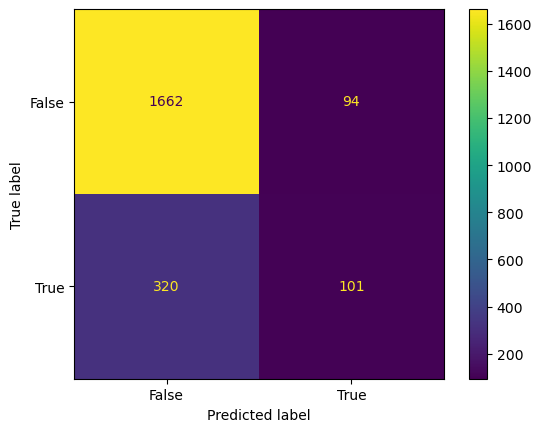

In [97]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test
)
plt.show()

Feature Importance Bar CHart

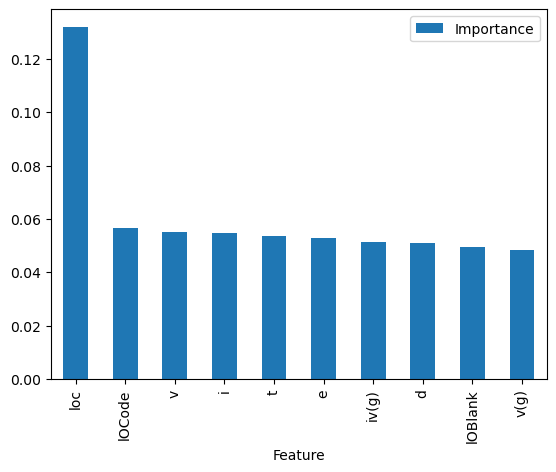

In [98]:
importance_df.head(10).plot(
    x='Feature',
    y='Importance',
    kind='bar'
)

plt.show()

In [99]:
import joblib

joblib.dump(rf, "defect_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [100]:
import joblib

model = joblib.load("defect_model.pkl")

print(type(model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


 Risk Scoring and Testing Priority Module

In [102]:


y_prob = rf.predict_proba(X_test)[:,1]

print(y_prob[:10])

[0.2  0.2  0.44 0.03 0.07 0.18 0.18 0.07 0.08 0.16]


In [103]:
risk_score = (y_prob * 100).round(2)

print(risk_score[:10])

[20. 20. 44.  3.  7. 18. 18.  7.  8. 16.]


In [104]:
def risk_level(score):
    
    if score <= 30:
        return "Low"
    
    elif score <= 70:
        return "Medium"
    
    else:
        return "High"

In [105]:
def testing_priority(level):
    
    if level == "High":
        return "Priority 1"
    
    elif level == "Medium":
        return "Priority 2"
    
    else:
        return "Priority 3"

In [106]:
import pandas as pd

report_df = pd.DataFrame({
    "Actual_Defect": y_test.values,
    "Risk_Score": risk_score
})

report_df["Risk_Level"] = report_df["Risk_Score"].apply(risk_level)

report_df["Testing_Priority"] = report_df["Risk_Level"].apply(testing_priority)

report_df.head(10)

,Actual_Defect,Risk_Score,Risk_Level,Testing_Priority
0,True,20.0,Low,Priority 3
1,False,20.0,Low,Priority 3
2,False,44.0,Medium,Priority 2
3,False,3.0,Low,Priority 3
4,False,7.0,Low,Priority 3
5,True,18.0,Low,Priority 3
6,False,18.0,Low,Priority 3
7,False,7.0,Low,Priority 3
8,True,8.0,Low,Priority 3
9,False,16.0,Low,Priority 3


 High Risk Module Analysis

In [107]:
high_risk = report_df[
    report_df["Risk_Level"] == "High"
]

print("Number of High Risk Modules:", len(high_risk))

high_risk.head(10)

Number of High Risk Modules: 59


,Actual_Defect,Risk_Score,Risk_Level,Testing_Priority
48,True,70.11,High,Priority 1
115,True,71.00,High,Priority 1
156,False,72.00,High,Priority 1
235,False,97.00,High,Priority 1
257,True,92.00,High,Priority 1
259,True,74.00,High,Priority 1
260,True,100.00,High,Priority 1
299,True,73.00,High,Priority 1
311,False,73.18,High,Priority 1
314,True,96.00,High,Priority 1


In [108]:
report_df["Risk_Level"].value_counts()

Risk_Level
Low       1651
Medium     467
High        59
Name: count, dtype: int64

Explainable Risk Insights

In [109]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(5)

,Feature,Importance
0,loc,0.131999
12,lOCode,0.056514
5,v,0.055093
8,i,0.054861
11,t,0.053605


In [110]:
top_features = feature_importance.head(3)["Feature"].tolist()

print("Top Risk Factors:")
for feature in top_features:
    print("-", feature)

Top Risk Factors:
- loc
- lOCode
- v


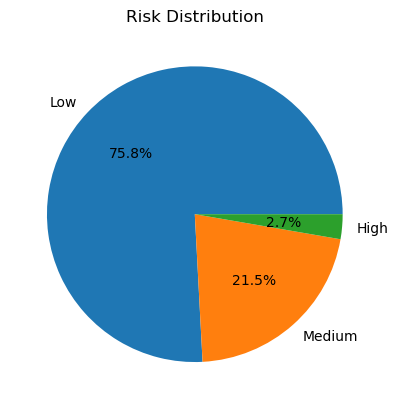

In [111]:
import matplotlib.pyplot as plt

report_df["Risk_Level"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Risk Distribution")
plt.ylabel("")
plt.show()

In [112]:
report_df.to_csv("risk_report.csv", index=False)

print("Risk report exported successfully!")

Risk report exported successfully!
